## Importing Libraries and load the txt file

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("chat.txt", header=None, on_bad_lines='skip', encoding='utf8')

In [3]:
df

,0,1
0,‎[26/02/25,9:57:33 PM] K@v!n: Anybody facing slack issue...
1,[26/02/25,9:57:50 PM] Diviya Fleet Team(verizon): Yes
2,[26/02/25,9:58:13 PM] Vignesh Verizon: Myself too for p...
3,[26/02/25,9:58:17 PM] Diviya Fleet Team(verizon): Aske...
4,[26/02/25,9:58:32 PM] Vignesh Verizon: Restarted the la...
...,...,...
704,‎[21/02/26,10:02:42 PM] Karthick Fleet: ‎image omitted
705,‎[21/02/26,10:02:43 PM] Karthick Fleet: ‎image omitted
706,‎[21/02/26,10:02:43 PM] Karthick Fleet: ‎image omitted
707,‎[21/02/26,10:02:44 PM] Karthick Fleet: ‎image omitted


## changig the columns name 

In [4]:
df.columns =['Date','chat']

In [5]:
df

,Date,chat
0,‎[26/02/25,9:57:33 PM] K@v!n: Anybody facing slack issue...
1,[26/02/25,9:57:50 PM] Diviya Fleet Team(verizon): Yes
2,[26/02/25,9:58:13 PM] Vignesh Verizon: Myself too for p...
3,[26/02/25,9:58:17 PM] Diviya Fleet Team(verizon): Aske...
4,[26/02/25,9:58:32 PM] Vignesh Verizon: Restarted the la...
...,...,...
704,‎[21/02/26,10:02:42 PM] Karthick Fleet: ‎image omitted
705,‎[21/02/26,10:02:43 PM] Karthick Fleet: ‎image omitted
706,‎[21/02/26,10:02:43 PM] Karthick Fleet: ‎image omitted
707,‎[21/02/26,10:02:44 PM] Karthick Fleet: ‎image omitted


## Spliting the columns

In [6]:
Message = df['chat'].str.split(']',n=1,expand=True)
df['Time']= Message[0]

In [7]:
df

,Date,chat,Time
0,‎[26/02/25,9:57:33 PM] K@v!n: Anybody facing slack issue...,9:57:33 PM
1,[26/02/25,9:57:50 PM] Diviya Fleet Team(verizon): Yes,9:57:50 PM
2,[26/02/25,9:58:13 PM] Vignesh Verizon: Myself too for p...,9:58:13 PM
3,[26/02/25,9:58:17 PM] Diviya Fleet Team(verizon): Aske...,9:58:17 PM
4,[26/02/25,9:58:32 PM] Vignesh Verizon: Restarted the la...,9:58:32 PM
...,...,...,...
704,‎[21/02/26,10:02:42 PM] Karthick Fleet: ‎image omitted,10:02:42 PM
705,‎[21/02/26,10:02:43 PM] Karthick Fleet: ‎image omitted,10:02:43 PM
706,‎[21/02/26,10:02:43 PM] Karthick Fleet: ‎image omitted,10:02:43 PM
707,‎[21/02/26,10:02:44 PM] Karthick Fleet: ‎image omitted,10:02:44 PM


In [8]:
Message1 = Message[1].str.split(':',n=1,expand=True)
df['Name']= Message1[0]
df['chat']= Message1[1]

In [9]:
df

,Date,chat,Time,Name
0,‎[26/02/25,Anybody facing slack issue? For me not able t...,9:57:33 PM,K@v!n
1,[26/02/25,Yes,9:57:50 PM,Diviya Fleet Team(verizon)
2,[26/02/25,Myself too for past twenty 20 minutes,9:58:13 PM,Vignesh Verizon
3,[26/02/25,Asked Deen to post in the channel,9:58:17 PM,Diviya Fleet Team(verizon)
4,[26/02/25,Restarted the laptop too..not working,9:58:32 PM,Vignesh Verizon
...,...,...,...,...
704,‎[21/02/26,‎image omitted,10:02:42 PM,Karthick Fleet
705,‎[21/02/26,‎image omitted,10:02:43 PM,Karthick Fleet
706,‎[21/02/26,‎image omitted,10:02:43 PM,Karthick Fleet
707,‎[21/02/26,‎image omitted,10:02:44 PM,Karthick Fleet


## Ordering the colums

In [10]:
df=df[["Date",'Time','Name','chat']]
df

,Date,Time,Name,chat
0,‎[26/02/25,9:57:33 PM,K@v!n,Anybody facing slack issue? For me not able t...
1,[26/02/25,9:57:50 PM,Diviya Fleet Team(verizon),Yes
2,[26/02/25,9:58:13 PM,Vignesh Verizon,Myself too for past twenty 20 minutes
3,[26/02/25,9:58:17 PM,Diviya Fleet Team(verizon),Asked Deen to post in the channel
4,[26/02/25,9:58:32 PM,Vignesh Verizon,Restarted the laptop too..not working
...,...,...,...,...
704,‎[21/02/26,10:02:42 PM,Karthick Fleet,‎image omitted
705,‎[21/02/26,10:02:43 PM,Karthick Fleet,‎image omitted
706,‎[21/02/26,10:02:43 PM,Karthick Fleet,‎image omitted
707,‎[21/02/26,10:02:44 PM,Karthick Fleet,‎image omitted


## Sentimental Analysis
### It help to identify the group coversation is postive or negative

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 709 entries, 0 to 708
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    709 non-null    str  
 1   Time    548 non-null    str  
 2   Name    532 non-null    str  
 3   chat    532 non-null    str  
dtypes: str(4)
memory usage: 22.3 KB


In [12]:
#!pip install nltk
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/kavin/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [13]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [14]:
dataset = df

In [15]:
dataset.dropna(inplace=True)

In [16]:
sid = SentimentIntensityAnalyzer()
senti = sid.polarity_scores(dataset['chat'][4])
senti

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

In [17]:
senti['compound']

0.0

In [18]:
def sentimentalAnalysis(data,columnname):
        
        #downloading vader_lexicon for the process
        import matplotlib.pyplot as plt
        import seaborn as sns
        "Importing Necessary Packeage"
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        sid = SentimentIntensityAnalyzer()
        
        "Deleting null pr empty value"
        data.dropna(inplace=True)
        
        "Checking for a comment"
        #sid.polarity_scores(data[columnname][93])
        
        "Creating respective columns"
        
        data['scores'] = data[columnname].apply(lambda commentText: sid.polarity_scores(commentText))
        data['compound']  = data['scores'].apply(lambda score_dict: score_dict['compound'])
        data['Negtive']  = data['scores'].apply(lambda score_dict: score_dict['neg'])
        data['Postive']  = data['scores'].apply(lambda score_dict: score_dict['pos'])
        data['Neutral']  = data['scores'].apply(lambda score_dict: score_dict['neu'])
        
        "Creating final pos or neg using compound score"
        data['comp_score'] = data['compound'].apply(lambda c: 'pos' if c >=0 else 'neg')
        plt.clf()
        #comp=sns.countplot(x = 'comp_score', hue = 'Name', data = data, palette = 'magma')
        #comp.figure.savefig("date_charts.png")
        "Checking how many pos and neg"
        posneg=pd.DataFrame(data['comp_score'].value_counts())
        return posneg,data

In [19]:
pos,data_Senti=sentimentalAnalysis(dataset,columnname='chat')

<Figure size 640x480 with 0 Axes>

In [20]:
data_Senti

,Date,Time,Name,chat,scores,compound,Negtive,Postive,Neutral,comp_score
0,‎[26/02/25,9:57:33 PM,K@v!n,Anybody facing slack issue? For me not able t...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos
1,[26/02/25,9:57:50 PM,Diviya Fleet Team(verizon),Yes,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...",0.4019,0.0,1.000,0.000,pos
2,[26/02/25,9:58:13 PM,Vignesh Verizon,Myself too for past twenty 20 minutes,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos
3,[26/02/25,9:58:17 PM,Diviya Fleet Team(verizon),Asked Deen to post in the channel,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos
4,[26/02/25,9:58:32 PM,Vignesh Verizon,Restarted the laptop too..not working,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos
...,...,...,...,...,...,...,...,...,...,...
704,‎[21/02/26,10:02:42 PM,Karthick Fleet,‎image omitted,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos
705,‎[21/02/26,10:02:43 PM,Karthick Fleet,‎image omitted,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos
706,‎[21/02/26,10:02:43 PM,Karthick Fleet,‎image omitted,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos
707,‎[21/02/26,10:02:44 PM,Karthick Fleet,‎image omitted,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos


In [21]:
pos

,count
comp_score,
pos,515
neg,17


## Topic Modeling ---> Unsupervised Algorithm
### It helps fliter the What topic is mainly or more in the chat conversation

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [23]:
tfidf=TfidfVectorizer(max_df=0.95,min_df=2,stop_words='english')
dtm=tfidf.fit_transform(df["chat"])

In [35]:
##LDA --> Latent Dirichlet Allocation
## Each document has multiple topics with probabilities -->This chat is 70% topic A, 30% topic B

In [25]:
from sklearn.decomposition import LatentDirichletAllocation
lda_model = LatentDirichletAllocation(n_components=5, random_state=42)
lda_model.fit(dtm)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [26]:
for index,topic in enumerate(lda_model.components_):
    results=([tfidf.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print(results)

['support', 'gif', 'day', 'congrats', 'great', 'aswath', 'guys', 'thank', 'sure', 'ullas']
['going', 'friday', 'david', 'armesh', 'resolved', 'working', 'omitted', 'issue', 'sent', 'video']
['daniel', 'code', 'changed', 'joshva', 'security', 'anand', 'ok', 'happy', 'birthday', 'verizon']
['venue', 'received', 'thanks', 'wishes', 'document', 'aws', 'deleted', 'message', 'yes', 'https']
['vz', 'manager', 'year', 'prince', 'birthday', 'diwali', 'team', 'happy', 'omitted', 'image']


In [28]:
topic_results=lda_model.transform(dtm)
df["Topic"]=topic_results.argmax(axis=1)

In [29]:
df

,Date,Time,Name,chat,scores,compound,Negtive,Postive,Neutral,comp_score,Topic
0,‎[26/02/25,9:57:33 PM,K@v!n,Anybody facing slack issue? For me not able t...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos,1
1,[26/02/25,9:57:50 PM,Diviya Fleet Team(verizon),Yes,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...",0.4019,0.0,1.000,0.000,pos,3
2,[26/02/25,9:58:13 PM,Vignesh Verizon,Myself too for past twenty 20 minutes,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos,1
3,[26/02/25,9:58:17 PM,Diviya Fleet Team(verizon),Asked Deen to post in the channel,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos,2
4,[26/02/25,9:58:32 PM,Vignesh Verizon,Restarted the laptop too..not working,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos,1
...,...,...,...,...,...,...,...,...,...,...,...
704,‎[21/02/26,10:02:42 PM,Karthick Fleet,‎image omitted,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos,4
705,‎[21/02/26,10:02:43 PM,Karthick Fleet,‎image omitted,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos,4
706,‎[21/02/26,10:02:43 PM,Karthick Fleet,‎image omitted,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos,4
707,‎[21/02/26,10:02:44 PM,Karthick Fleet,‎image omitted,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.0,0.000,1.000,pos,4


In [31]:
df["Topic"].value_counts()

Topic
4    156
2    122
0     93
3     81
1     80
Name: count, dtype: int64

## Wordcloud

In [32]:
#!pip install wordCloud

In [33]:
dataset=df
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import matplotlib.pyplot as plt
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /Users/kavin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

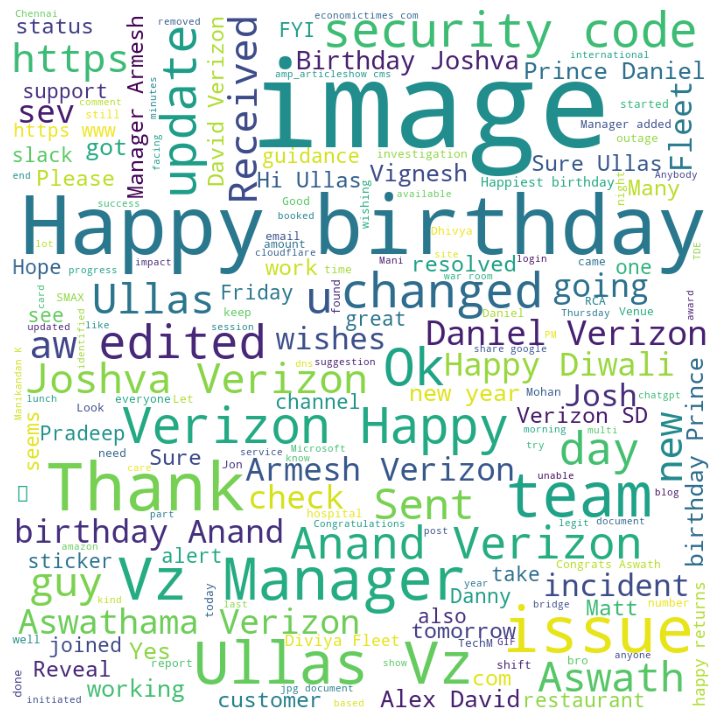

✅ WordCloud created successfully


In [34]:
from wordcloud import WordCloud
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

# Stopwords
stoplist = stopwords.words('english')
stoplist.extend(['omitted','voice','missed','call','video','deleted','media','message'])

# Ensure no NaN and convert to string
text_data = dataset['chat'].dropna().astype(str)

# Combine all text at once (IMPORTANT)
all_text = " ".join(text_data)

# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    stopwords=stoplist,
    min_font_size=10
).generate(all_text)

# Plot
plt.figure(figsize=(9, 7))
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)

# Save
plt.savefig('wordcloud.png')
plt.show()

print("✅ WordCloud created successfully")

## Flirt Encounters

In [36]:
flirt_words = [
    'love','miss you','baby','babe','dear','sweet','kiss','hug',
    'cutie','beautiful','handsome','😍','😘','❤️','💕','😚'
]

def detect_flirt(text):
    text = str(text).lower()
    return any(word in text for word in flirt_words)

dataset['flirt'] = dataset['chat'].apply(detect_flirt)

In [37]:
flirt_count = dataset['flirt'].sum()
print("Total Flirt Messages:", flirt_count)

Total Flirt Messages: 4


## Media Encounters

In [38]:
def detect_media(text):
    text = str(text).lower()
    return 'media omitted' in text or '<media omitted>' in text

dataset['media'] = dataset['chat'].apply(detect_media)

In [39]:
media_count = dataset['media'].sum()
print("Total Media Messages:", media_count)

Total Media Messages: 0


In [40]:
print("Total Messages:", len(dataset))
print("Flirt Messages:", dataset['flirt'].sum())
print("Media Messages:", dataset['media'].sum())

Total Messages: 532
Flirt Messages: 4
Media Messages: 0
